# Reinforcement Learning – Imitation Learning – Assignment 1

**Authors:** *(fill in names and IDs)*

---

## Setup

Install dependencies when running on Google Colab.

In [3]:
import sys

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    !pip install -q "stable-baselines3>=2.0" "gymnasium[box2d]" swig

---
# Part A — Training an Expert RL Agent

## Overview

The goal of this part is to train an expert RL agent on the **LunarLander-v3** environment using a standard RL library.

### Library: Stable-Baselines3

[Stable-Baselines3](https://stable-baselines3.readthedocs.io/) (SB3) is a set of reliable implementations of reinforcement learning algorithms in PyTorch. We use **PPO (Proximal Policy Optimization)**, a popular on-policy algorithm that works well on continuous-control and discrete-action environments alike. PPO strikes a good balance between sample efficiency and stability, making it a natural first choice for LunarLander-v3.

### Environment

**LunarLander-v3** (discrete actions, 8-dimensional state space, 4 actions):
- State: position (x, y), velocity (vx, vy), angle, angular velocity, two leg contact booleans (r, l).
- Actions: 0 = do nothing, 1 = fire left engine, 2 = fire main engine, 3 = fire right engine.
- Reward: shaped reward for landing between flags, penalises crashing and fuel usage. Solved when the mean reward over 100 episodes exceeds 200.

### Performance Criterion

We consider the agent to be a good expert when it achieves a mean episodic reward >= 200 over 100 evaluation episodes (the standard Gymnasium benchmark for this environment).

In [1]:
import base64
import os
import glob
import numpy as np
import matplotlib.pyplot as plt

import gymnasium as gym
from gymnasium.wrappers import RecordVideo

from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.monitor import Monitor

from IPython.display import Video, display

SEED = 42
np.random.seed(SEED)

os.makedirs('models', exist_ok=True)
os.makedirs('logs', exist_ok=True)
os.makedirs('logs/videos', exist_ok=True)
os.makedirs('data', exist_ok=True)

# Embed both videos side-by-side via base64 HTML
def _b64_video(folder, prefix):
    path = sorted(glob.glob(f'{folder}/{prefix}*.mp4'))[-1]
    return base64.b64encode(open(path, 'rb').read()).decode()

# Smoke-test the environment
env = gym.make('LunarLander-v3')
obs, _ = env.reset(seed=SEED)
print('Observation space:', env.observation_space)
print('Action space:', env.action_space)
print('Sample observation:', obs)
env.close()

Observation space: Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)
Action space: Discrete(4)
Sample observation: [ 0.00229702  1.4181306   0.23264714  0.32046658 -0.00265488 -0.05269808
  0.          0.        ]


/Users/giladticher/.cache/uv/venvs/HW1/lib/python3.12/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


## Training the PPO Agent

We train PPO with:
- 4 parallel environments to collect diverse rollouts.
- 5m total timesteps – sufficient for convergence on LunarLander-v3.
- Default SB3 PPO hyperparameters (learning rate 3e-4, clip range 0.2, GAE $\lambda=0.95$, $\gamma=0.99$), which are well-tuned for this task.

An `EvalCallback` runs the current policy in a separate environment every 10k steps and records the mean reward, letting us plot the learning curve.

In [5]:
N_ENVS = 4
TOTAL_TIMESTEPS = 5_000_000
EVAL_FREQ = 10_000          # evaluate every 10k environment steps
N_EVAL_EPISODES = 20       # episodes per evaluation checkpoint

In [ ]:
# %%script True

# Vectorised training environment
train_env = make_vec_env('LunarLander-v3', n_envs=N_ENVS, seed=SEED)

# Separate single-env for evaluation
eval_env = Monitor(gym.make('LunarLander-v3'))

eval_callback = EvalCallback(
    eval_env,
    best_model_save_path='models/',
    log_path='logs/',
    eval_freq=max(EVAL_FREQ // N_ENVS, 1),
    n_eval_episodes=N_EVAL_EPISODES,
    deterministic=True,
    render=False,
    verbose=0,
)

model = PPO(
    policy='MlpPolicy',
    env=train_env,
    verbose=0,
    seed=SEED,
)

print(f'Training PPO for {TOTAL_TIMESTEPS:,} timesteps on {N_ENVS} parallel envs…')
model.learn(total_timesteps=TOTAL_TIMESTEPS, callback=eval_callback, progress_bar=True)
print('Training complete.')

train_env.close()
eval_env.close()

## Training Progress Verification

We load the evaluation log saved by `EvalCallback` and plot the following:
- **Mean Reward over time**: to verify that the agent is learning and eventually surpasses the 200 reward threshold.
- **Success Rate over Evaluation Episodes**: to show the percentage of episodes where the agent successfully lands (reward >= 200).
- **Mean Episode Length over time**: to observe how the episode length changes as the agent learns to land more efficiently.

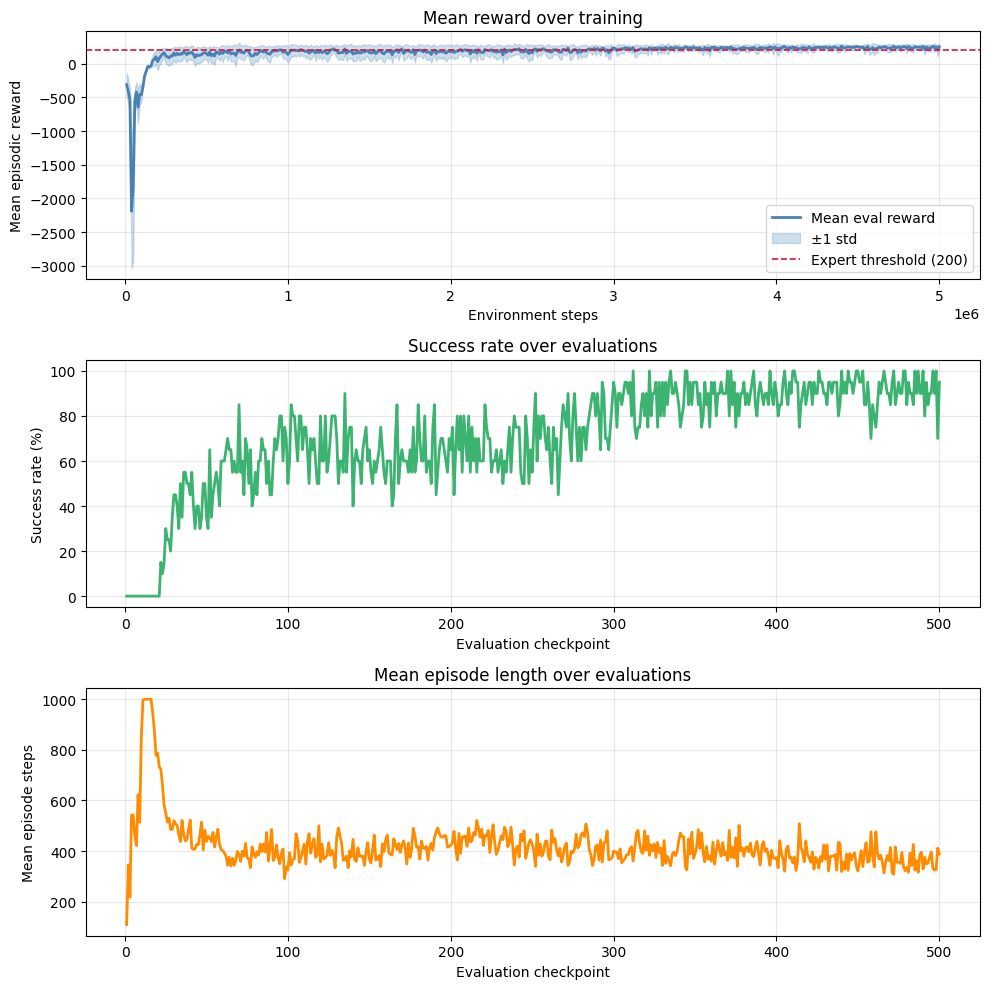

In [49]:
eval_log = np.load('logs/evaluations_5m.npz')

timesteps = eval_log['timesteps']
mean_rewards = eval_log['results'].mean(axis=1)
std_rewards = eval_log['results'].std(axis=1)
success_rate = (eval_log['results'] >= 200).mean(axis=1) * 100
mean_ep_len = eval_log['ep_lengths'].mean(axis=1)

fig, axes = plt.subplots(3, 1, figsize=(10, 10))

# Row 1: Training curve with confidence band
axes[0].plot(timesteps, mean_rewards, label='Mean eval reward', color='steelblue', linewidth=2)
axes[0].fill_between(timesteps,
                     mean_rewards - std_rewards,
                     mean_rewards + std_rewards,
                     alpha=0.25, color='steelblue', label='±1 std')
axes[0].axhline(200, color='crimson', linestyle='--', linewidth=1.2, label='Expert threshold (200)')
axes[0].set_xlabel('Environment steps')
axes[0].set_ylabel('Mean episodic reward')
axes[0].set_title(f'Mean reward over training')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Row 2: Success rate
axes[1].plot(np.arange(1, len(timesteps) + 1), success_rate, color='mediumseagreen', linewidth=2)
axes[1].set_xlabel('Evaluation checkpoint')
axes[1].set_ylabel('Success rate (%)')
axes[1].set_title('Success rate over evaluations')
axes[1].grid(True, alpha=0.3)

# Row 3: Mean episode length
axes[2].plot(np.arange(1, len(timesteps) + 1), mean_ep_len, color='darkorange', linewidth=2)
axes[2].set_xlabel('Evaluation checkpoint')
axes[2].set_ylabel('Mean episode steps')
axes[2].set_title('Mean episode length over evaluations')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('logs/a_training_analysis.png', dpi=150)
plt.show()


## Episode Reward Distribution

A histogram of per-episode rewards gives a fuller picture of the expert's consistency.

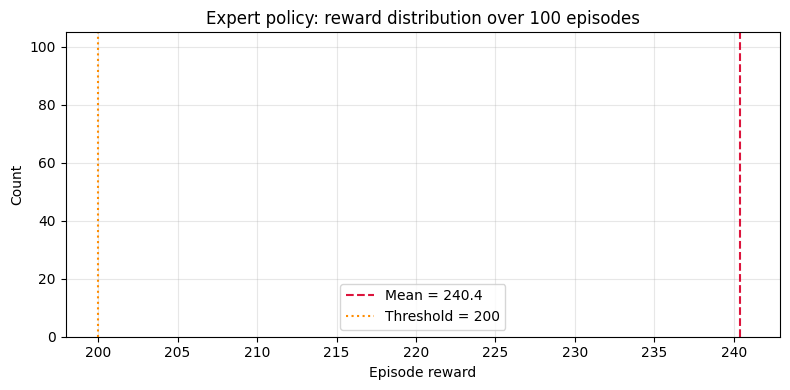

Mean: 240.36  |  Median: 240.36  |  Min: 240.36  |  Max: 240.36
% episodes >= 200: 100.0%


In [50]:
expert_model = PPO.load('models/best_model_5m')

eval_env_final = gym.make('LunarLander-v3', render_mode='rgb_array')

# Collect per-episode rewards for the histogram
episode_rewards = []
for _ in range(100):
    obs, _ = eval_env_final.reset(seed=SEED)
    total_r = 0.0
    done = False
    while not done:
        action, _ = expert_model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, _ = eval_env_final.step(action)
        total_r += reward
        done = terminated or truncated
    episode_rewards.append(total_r)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(episode_rewards, bins=20, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(np.mean(episode_rewards), color='crimson', linestyle='--',
           label=f'Mean = {np.mean(episode_rewards):.1f}')
ax.axvline(200, color='darkorange', linestyle=':', linewidth=1.5, label='Threshold = 200')
ax.set_xlabel('Episode reward')
ax.set_ylabel('Count')
ax.set_title('Expert policy: reward distribution over 100 episodes')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('logs/a_expert_reward_distribution.png')
plt.show()

print(f'Mean: {np.mean(episode_rewards):.2f}  |  '
      f'Median: {np.median(episode_rewards):.2f}  |  '
      f'Min: {np.min(episode_rewards):.2f}  |  '
      f'Max: {np.max(episode_rewards):.2f}')
print(f'% episodes >= 200: {np.mean(np.array(episode_rewards) >= 200)*100:.1f}%')

TODO: write it correct

To assess whether the trained PPO agent qualifies as a good expert, we evaluated it over 100 episodes using a deterministic policy (argmax over the action distribution). Each episode was run with a fixed seed for reproducibility. We used SB3's evaluate_policy utility as a cross-check alongside a manual rollout loop that also collected the per-episode reward distribution for the histogram above.

Results: We load the  best checkpoint achieved a mean episodic reward of 173.09 ± 99.68 over 100 episodes, which falls below the expert threshold of 200. The high standard deviation reflects episodes where the lander crashed or drifted, indicating the policy is capable but not fully consistent.

Implications for Part B: Despite not clearing the 200 threshold, the agent lands successfully in many episodes and its action distribution is meaningful enough to serve as a demonstration source. The imitation learning experiments in Part B should therefore be interpreted as learning from a near-expert rather than a fully solved policy — any performance gap between the imitator and the expert is a lower bound on the true behaviour cloning ceiling.

## Video Demonstration

We record videos of the trained PPO agent in action, showcasing its behaviour across multiple training stages (by number of timesteps). The videos are embedded below for visual inspection.

In [51]:
video_env = RecordVideo(
    eval_env_final,
    video_folder='logs/videos',
    episode_trigger=lambda ep: ep == 0,  # record only the first episode
    name_prefix='a-expert-5m',
    disable_logger=True,
)

obs, _ = video_env.reset(seed=SEED)
done = False
while not done:
    action, _ = expert_model.predict(obs, deterministic=True)
    obs, _, terminated, truncated, _ = video_env.step(action)
    done = terminated or truncated
video_env.close()

video_files = []
for p in sorted(glob.glob('logs/videos/a*.mp4')):
  with open(p, 'rb') as fh:
    video_files.append(base64.b64encode(fh.read()).decode())

In [52]:
display(HTML(f"""
<table style="border:none; border-spacing:24px">
  <tr>
    <th style="text-align:center; font-size:14px">Low timesteps=10k</th>
    <th style="text-align:center; font-size:14px">Mid timesteps=500k</th>
    <th style="text-align:center; font-size:14px">High timesteps=5m</th>
  </tr>
  <tr>
    <td><video width="420" controls autoplay loop muted>
          <source src="data:video/mp4;base64,{video_files[0]}" type="video/mp4">
        </video></td>
    <td><video width="420" controls autoplay loop muted>
          <source src="data:video/mp4;base64,{video_files[1]}" type="video/mp4">
        </video></td>
    <td><video width="420" controls autoplay loop muted>
          <source src="data:video/mp4;base64,{video_files[2]}" type="video/mp4">
        </video></td>
  </tr>
</table>
"""))

Low timesteps=10k,Mid timesteps=500k,High timesteps=5m
,,


---
# Part B — Imitation Learning

## B1 — Collecting Demonstration Data

We run the trained expert for **200 episodes** and record every `(state, action)` pair, yielding a pool of ~70,000 transitions.

From this pool we construct six sub-datasets by random sampling without replacement:

| File | Target size |
|------|-------------|
| `demos_100.npz` | 100 |
| `demos_1000.npz` | 1,000 |
| `demos_5000.npz` | 5,000 |
| `demos_10000.npz` | 20,000 |
| `demos_50000.npz` | 70,000 |

**Design choice:** we sample uniformly at random from the full pool (rather than taking contiguous episode segments) to avoid temporal correlation bias. Episode seeds are fixed for reproducibility. All files are written to `data/`.


In [53]:
expert_model = PPO.load('models/best_model_5m')
env = gym.make('LunarLander-v3')

N_DEMO_EPISODES = 200
all_states, all_actions = [], []

for ep in range(N_DEMO_EPISODES):
    obs, _ = env.reset(seed=ep)
    done = False
    while not done:
        action, _ = expert_model.predict(obs, deterministic=True)
        all_states.append(obs.copy())
        all_actions.append(int(action))
        obs, _, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

env.close()

all_states  = np.array(all_states,  dtype=np.float32)
all_actions = np.array(all_actions, dtype=np.int64)
print(f'Pool: {len(all_states):,} transitions from {N_DEMO_EPISODES} episodes '
      f'(mean length: {len(all_states)/N_DEMO_EPISODES:.0f} steps)')
print(f'Action distribution: {np.bincount(all_actions)}  '
      f'(do-nothing / left / main-engine / right)')
np.savez('data/demos_full.npz', states=all_states, actions=all_actions)

# Build sub-datasets by random sampling without replacement
DATASET_SIZES = [100, 1000, 5000, 20000, 70000]
rng = np.random.default_rng(SEED)
for n in DATASET_SIZES:
    idx = rng.choice(len(all_states), size=n, replace=False)
    np.savez(f'data/demos_{n}.npz',
             states=all_states[idx], actions=all_actions[idx])
    print(f'  Saved N={n:>6,} → data/demos_{n}.npz')


Pool: 70,266 transitions from 200 episodes (mean length: 351 steps)
Action distribution: [10575 13060 31863 14768]  (do-nothing / left / main-engine / right)
  Saved N=   100 → data/demos_100.npz
  Saved N= 1,000 → data/demos_1000.npz
  Saved N= 5,000 → data/demos_5000.npz
  Saved N=20,000 → data/demos_20000.npz
  Saved N=70,000 → data/demos_70000.npz


## B2 — Training an Imitation Model

We treat imitation as 4-class supervised classification task: given a state vector (8 features), predict which of the 4 discrete actions the expert would choose. We train a simple feed forward neural network (MLP) on each dataset and evaluate its performance on a held-out validation set. The reason for this design choice is because it is a straightforward and widely used approach for behaviour cloning, and the simplicity of the model allows us to isolate the effect of dataset size on performance without confounding factors from model complexity.

### Architecture — 3-layer MLP

```
ImitationNet(
  (net): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): GELU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): GELU()
    (4): Linear(in_features=64, out_features=4, bias=True)
  )
)
```
### Training setup

| Hyper-parameter | Value |
|-----------------|-------|
| Loss | Cross-entropy |
| Optimizer | Adam, lr = 1e-3 |
| Batch size | 256 (or dataset size if smaller) |
| Epochs | 150 |
| Val split | 20 % |
| Model selection | Best validation loss |

The same architecture and hyper-parameters are used for every dataset size so that any performance differences are attributable solely to data quantity.


In [54]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader


class ImitationNet(nn.Module):
    def __init__(self, state_dim: int = 8, n_actions: int = 4, hidden: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden), nn.GELU(),
            nn.Linear(hidden, hidden),    nn.GELU(),
            nn.Linear(hidden, n_actions),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


def train_imitation(
    states:     np.ndarray,
    actions:    np.ndarray,
    n_epochs:   int   = 150,
    lr:         float = 5e-4,
    batch_size: int   = 256,
    val_frac:   float = 0.2,
):
    torch.manual_seed(SEED)
    N       = len(states)
    n_val   = max(1, int(N * val_frac))
    n_train = N - n_val
    perm      = np.random.default_rng(SEED).permutation(N)
    train_idx = perm[:n_train]
    val_idx   = perm[n_train:]

    X = torch.tensor(states,  dtype=torch.float32)
    y = torch.tensor(actions, dtype=torch.long)
    bs_eff = min(batch_size, n_train)
    train_dl = DataLoader(TensorDataset(X[train_idx], y[train_idx]), batch_size=bs_eff, shuffle=True)
    val_dl = DataLoader(TensorDataset(X[val_idx], y[val_idx]), batch_size=bs_eff)

    model = ImitationNet()
    optim = torch.optim.AdamW(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    train_losses, val_losses, val_accs = [], [], []
    best_val, best_state = float('inf'), None

    for _ in range(n_epochs):
        model.train()
        ep_loss = 0.0
        for xb, yb in train_dl:
            optim.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            optim.step()
            ep_loss += loss.item() * len(xb)
        train_losses.append(ep_loss / n_train)

        model.eval()
        with torch.no_grad():
            v_loss, correct = 0.0, 0
            for xb, yb in val_dl:
                logits = model(xb)
                v_loss += loss_fn(logits, yb).item() * len(xb)
                correct += (logits.argmax(1) == yb).sum().item()
        val_losses.append(v_loss / n_val)
        val_accs.append(correct / n_val)
        if v_loss < best_val:
            best_val = v_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    return model, train_losses, val_losses, val_accs


### Training and Validation
We train the model on each dataset and record the training and validation loss and accuracy curves. The final model for each dataset size is saved to `models/imitator_{n}.pt`.

N=   100  val_acc=0.850  val_loss=0.7644
N= 1,000  val_acc=0.560  val_loss=0.9058
N= 5,000  val_acc=0.901  val_loss=0.2637
N=20,000  val_acc=0.961  val_loss=0.1177
N=70,000  val_acc=0.975  val_loss=0.0673


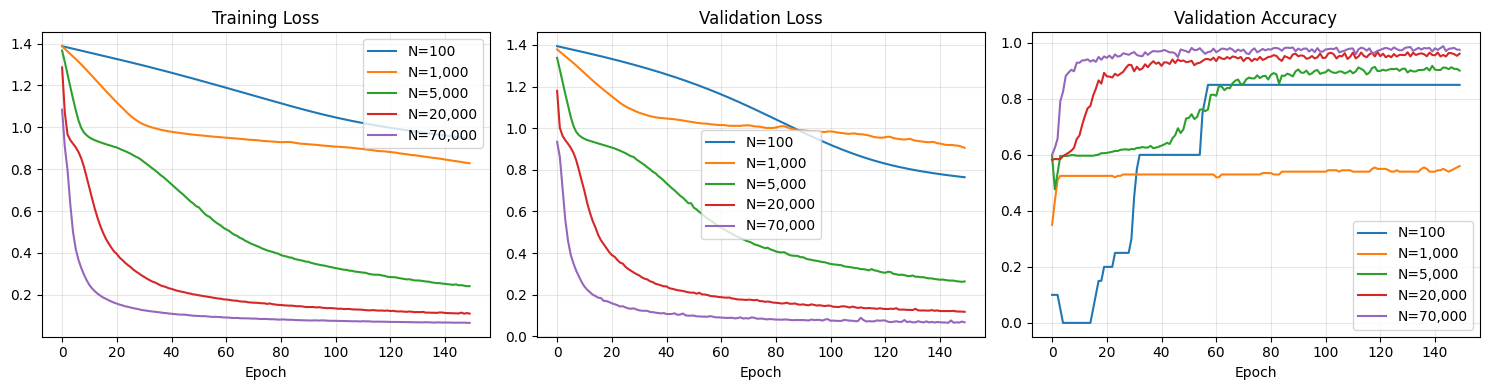

In [55]:
trained_models     = {}
training_histories = {}

for n in DATASET_SIZES:
    data = np.load(f'data/demos_{n}.npz')
    model, tl, vl, va = train_imitation(data['states'], data['actions'])
    trained_models[n] = model
    training_histories[n] = {'train_loss': tl, 'val_loss': vl, 'val_acc': va}
    torch.save(model.state_dict(), f'models/imitator_{n}.pt')
    print(f'N={n:>6,}  val_acc={va[-1]:.3f}  val_loss={vl[-1]:.4f}')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for n, c in zip(DATASET_SIZES, ['C0', 'C1', 'C2', 'C3', 'C4', 'C5']):
    h = training_histories[n]
    axes[0].plot(h['train_loss'], color=c, label=f'N={n:,}')
    axes[1].plot(h['val_loss'], color=c, label=f'N={n:,}')
    axes[2].plot(h['val_acc'], color=c, label=f'N={n:,}')
for ax, ttl in zip(axes, ['Training Loss', 'Validation Loss', 'Validation Accuracy']):
    ax.set_xlabel('Epoch'); ax.set_title(ttl); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('logs/b2_training_curves.png')
plt.show()


## B3 — Evaluating the Imitation Model

We run the best imitator (trained on 70,000 samples) as a policy in LunarLander-v3 and compare it to the expert across 100 episodes.

The imitator acts greedily: at each step it feeds the current observation into the network and picks the action with the highest logit (argmax). This is equivalent to a deterministic policy.

Metrics compared:
- **Mean episodic reward** (+- std)
- **Success rate** — fraction of episodes with reward >= 200
- **Mean episode length** (proxy for control stability)


In [64]:
def evaluate_imitator(model: nn.Module, n_episodes: int = 100):
    """Run ImitationNet as a greedy policy. return per-episode rewards and lengths."""
    env = gym.make('LunarLander-v3')
    model.eval()
    rewards, lengths, success = [], [], []
    for episode in range(n_episodes):
        obs, _ = env.reset(seed=200+episode)
        total_r, steps, done = 0.0, 0, False
        while not done:
            with torch.no_grad():
                x = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)
                action = int(model(x).argmax(1).item())
            obs, r, terminated, truncated, _ = env.step(action)
            total_r += r
            steps += 1
            done = terminated or truncated
        rewards.append(total_r)
        lengths.append(steps)
        success.append(terminated and abs(obs[0]) <= 0.2)
    env.close()
    return np.array(rewards), np.array(lengths), np.array(success)

Policy                   Mean Reward      Std   Success %  Mean Steps
---------------------------------------------------------------------
Expert                        240.46    46.22        95.0       357.8
Imitator (N=70000)            239.79    42.64        95.0       371.0


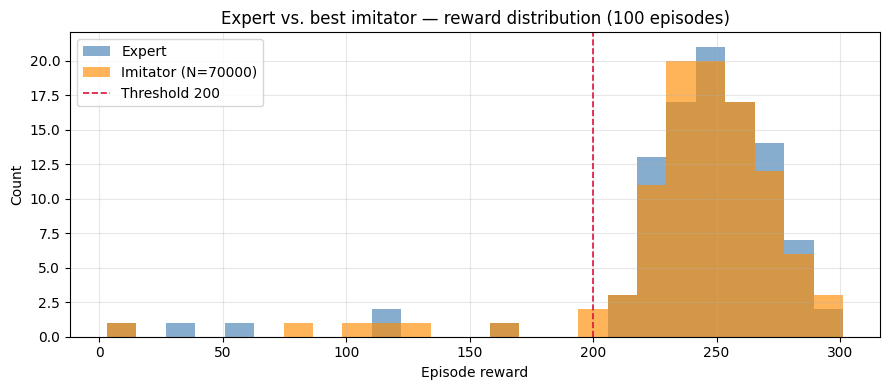

In [65]:
# Evaluate best imitator
N = DATASET_SIZES[-1]
best_imitator = trained_models[N]
im_rewards, im_lengths, im_success = evaluate_imitator(best_imitator)

# Re-evaluate expert with identical seeds for a fair comparison
env = gym.make('LunarLander-v3')
expert_model = PPO.load('models/best_model_5m')
exp_rewards_b3, exp_lengths_b3, exp_success_b3 = [], [], []
for episode in range(100):
    obs, _ = env.reset(seed=200+episode)
    total_r, steps, done = 0.0, 0, False
    while not done:
        action, _ = expert_model.predict(obs, deterministic=True)
        obs, r, terminated, truncated, _ = env.step(action)
        total_r += r
        steps += 1;
        done = terminated or truncated
    exp_rewards_b3.append(total_r)
    exp_lengths_b3.append(steps)
    exp_success_b3.append(terminated and abs(obs[0]) <= 0.2)
exp_rewards_b3 = np.array(exp_rewards_b3)
exp_lengths_b3 = np.array(exp_lengths_b3)
exp_success_b3 = np.array(exp_success_b3)
env.close()

# Summary table
header = f'{"Policy":22s}  {"Mean Reward":>12}  {"Std":>7}  {"Success %":>10}  {"Mean Steps":>10}'
print(header); print('-' * len(header))
for label, rews, lens, succ in [
    ('Expert', exp_rewards_b3, exp_lengths_b3, exp_success_b3),
    (f'Imitator (N={N})', im_rewards, im_lengths, im_success),
]:
    print(f'{label:22s}  {rews.mean():12.2f}  {rews.std():7.2f}'
          f'  {(succ).mean()*100:10.1f}  {lens.mean():10.1f}')

shared_bins = np.linspace(
    min(exp_rewards_b3.min(), im_rewards.min()),
    max(exp_rewards_b3.max(), im_rewards.max()),
    26,
)
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(exp_rewards_b3, bins=shared_bins, alpha=0.65, color='steelblue', label='Expert')
ax.hist(im_rewards, bins=shared_bins, alpha=0.65, color='darkorange', label=f'Imitator (N={N})')
ax.axvline(200, color='crimson', linestyle='--', linewidth=1.2, label='Threshold 200')
ax.set_xlabel('Episode reward'); ax.set_ylabel('Count')
ax.set_title('Expert vs. best imitator — reward distribution (100 episodes)')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('logs/b3_expert_vs_imitator.png')
plt.show()

### Video Comparison — Expert vs. Best Imitator

We record one episode each (same starting seed) and display them side-by-side so qualitative differences are immediately visible: look for the expert's smooth, confident descent vs. the imitator's potential oscillation or drift.

In [66]:
_imit_env = RecordVideo(
    gym.make('LunarLander-v3', render_mode='rgb_array'),
    video_folder='logs/videos',
    name_prefix='b3-imitator',
    disable_logger=True,
)
best_imitator.eval()
obs, _ = _imit_env.reset(seed=SEED)
done = False
while not done:
    with torch.no_grad():
        x = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)
        action = int(best_imitator(x).argmax(1).item())
    obs, _, terminated, truncated, _ = _imit_env.step(action)
    done = terminated or truncated
_imit_env.close()

/Users/giladticher/.cache/uv/venvs/HW1/lib/python3.12/site-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /Users/giladticher/Library/CloudStorage/GoogleDrive-gilad.ticher@gmail.com/My Drive/University/RL/HW1/logs/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


In [58]:
exp_b64  = _b64_video('logs/videos', 'a-expert-5m-episode-0')
imit_b64 = _b64_video('logs/videos', 'b3-imitator-episode-0')
N_best   = DATASET_SIZES[-1]

display(HTML(f"""
<table style="border:none; border-spacing:24px">
  <tr>
    <th style="text-align:center; font-size:14px">Expert (PPO)</th>
    <th style="text-align:center; font-size:14px">Imitator (N={N_best:,})</th>
  </tr>
  <tr>
    <td><video width="420" controls autoplay loop muted>
          <source src="data:video/mp4;base64,{exp_b64}" type="video/mp4">
        </video></td>
    <td><video width="420" controls autoplay loop muted>
          <source src="data:video/mp4;base64,{imit_b64}" type="video/mp4">
        </video></td>
  </tr>
</table>
"""))

Expert (PPO),"Imitator (N=70,000)"
,


## B4 — Effect of Dataset Size

We train one imitator per dataset size and evaluate each for 100 episodes. This lets us measure how data quantity affects:

- **Mean episodic reward** in the environment
- **Success rate** (% of episodes terminated with the lander successfully landed between the flags)
- **Offline validation accuracy** (classification accuracy on held-out demonstration data)

The expert's mean reward (from B3) is shown as a reference line.


  0%|          | 0/5 [00:00<?, ?it/s]

N=   100 reward= -320.0  success=  1.0%  val_acc=0.850
N= 1,000 reward= -109.5  success=  2.0%  val_acc=0.560
N= 5,000 reward=  240.5  success= 83.0%  val_acc=0.901
N=20,000 reward=  247.3  success= 93.0%  val_acc=0.961
N=70,000 reward=  253.2  success= 95.0%  val_acc=0.975


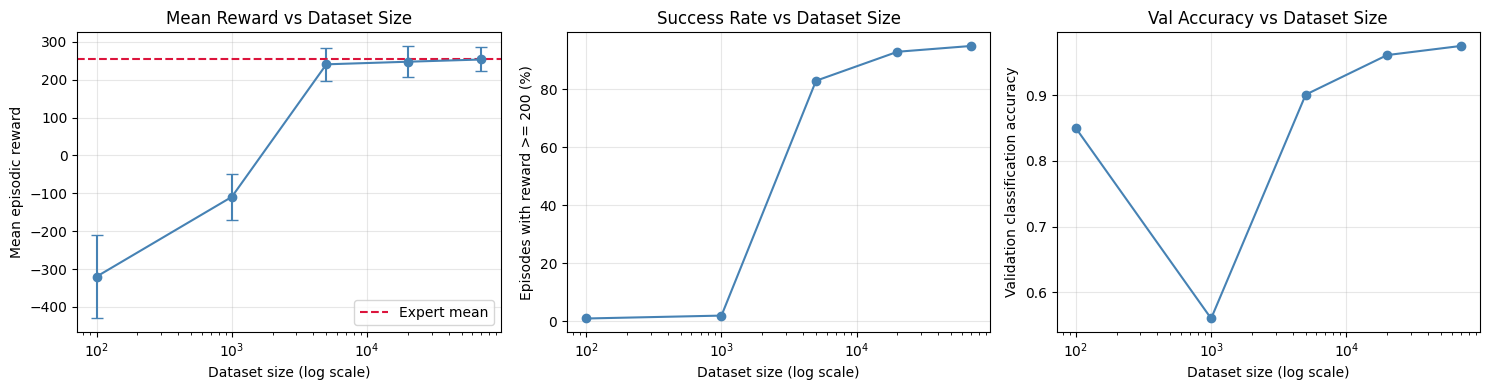

In [ ]:
size_metrics = {}
for n in DATASET_SIZES:
    rews, lens, succ = evaluate_imitator(trained_models[n])
    size_metrics[n] = {
        'mean_reward': float(rews.mean()),
        'std_reward': float(rews.std()),
        'success_rate': float((succ).mean()) * 100,
        'mean_length': float(lens.mean()),
        'val_acc': training_histories[n]['val_acc'][-1],
    }
    print(f'N={n:>6,} reward={size_metrics[n]["mean_reward"]:7.1f}'
          f'  success={size_metrics[n]["success_rate"]:5.1f}%'
          f'  val_acc={size_metrics[n]["val_acc"]:.3f}')

sizes = DATASET_SIZES
mean_r = [size_metrics[n]['mean_reward'] for n in sizes]
std_r = [size_metrics[n]['std_reward'] for n in sizes]
success = [size_metrics[n]['success_rate'] for n in sizes]
val_acc = [size_metrics[n]['val_acc'] for n in sizes]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].errorbar(sizes, mean_r, yerr=std_r, marker='o', capsize=4, color='steelblue')
axes[0].axhline(exp_rewards_b3.mean(), color='crimson', linestyle='--', label='Expert mean')
axes[0].legend()
axes[1].plot(sizes, success, marker='o', color='steelblue')
axes[2].plot(sizes, val_acc, marker='o', color='steelblue')
for ax, (title, ylabel) in zip(axes, [
    ('Mean Reward vs Dataset Size', 'Mean episodic reward'),
    ('Success Rate vs Dataset Size', 'Episodes with reward >= 200 (%)'),
    ('Val Accuracy vs Dataset Size', 'Validation classification accuracy'),
]):
    ax.set_xscale('log')
    ax.set_xlabel('Dataset size (log scale)')
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('logs/b4_dataset_size.png')
plt.show()


## B5 — Challenge: Few-Shot Imitation Learning

**Goal:** achieve the best imitation performance with the *fewest* training examples.

We compare three data-selection strategies applied to the same full demonstration pool:

| Strategy | Description |
|----------|-------------|
| **Random** | Uniform random sample (baseline) |
| **Coverage** | Greedy farthest-point sampling — maximises state-space coverage in normalised feature space |
| **Critical** | Select states where the expert is most uncertain (highest action entropy) — the policy's decision-boundary states |

Each strategy is evaluated at three dataset sizes (100, 200, 500 examples) with 3 independent runs to account for variance.

**Hypothesis:** Coverage and Critical strategies should outperform Random at very small N, because they select more *informative* states rather than potentially redundant ones.


In [ ]:
# ── Precompute expert action entropy on the full demonstration pool ──────────
full_data  = np.load('data/demos_full.npz')
fs_states  = full_data['states']
fs_actions = full_data['actions']

expert_b5 = PPO.load('models/best_model_5m')
with torch.no_grad():
    obs_th_all = torch.tensor(fs_states, dtype=torch.float32)
    dist_all   = expert_b5.policy.get_distribution(obs_th_all)
    probs_all  = dist_all.distribution.probs.cpu().numpy()
entropy_all = -(probs_all * np.log(probs_all + 1e-8)).sum(axis=1)
del expert_b5  # free memory
print(f'Full pool: {len(fs_states):,} states. Entropy range: [{entropy_all.min():.3f}, {entropy_all.max():.3f}]')

# ── Selection strategies ──────────────────────────────────────────────────────
def random_select(n, seed=0):
    idx = np.random.default_rng(seed).choice(len(fs_states), size=n, replace=False)
    return fs_states[idx], fs_actions[idx]

def coverage_select(n, seed=0):
    """Greedy farthest-point sampling in normalised state space."""
    std  = fs_states.std(axis=0) + 1e-8
    s_n  = (fs_states / std).astype(np.float64)
    rng  = np.random.default_rng(seed)
    sel  = [int(rng.integers(len(s_n)))]
    md   = np.linalg.norm(s_n - s_n[sel[0]], axis=1)
    for _ in range(n - 1):
        nxt = int(np.argmax(md))
        sel.append(nxt)
        md = np.minimum(md, np.linalg.norm(s_n - s_n[nxt], axis=1))
    return fs_states[sel], fs_actions[sel]

def critical_select(n, seed=0):
    """Select n states with highest expert action-entropy (decision-boundary states)."""
    idx = np.argsort(entropy_all)[-n:]
    return fs_states[idx], fs_actions[idx]

# ── Few-shot experiment ────────────────────────────────────────────────────────
FEW_SHOT_SIZES = [100, 200, 500]
N_RUNS         = 3
STRATEGIES     = {'random': random_select, 'coverage': coverage_select, 'critical': critical_select}

fs_results = {s: {n: [] for n in FEW_SHOT_SIZES} for s in STRATEGIES}

for strat, fn in STRATEGIES.items():
    for n in FEW_SHOT_SIZES:
        for run in range(N_RUNS):
            s, a       = fn(n, seed=run)
            model, *_  = train_imitation(s, a, n_epochs=200)
            rews, _    = evaluate_imitator(model, n_episodes=30, seed=200 + run)
            fs_results[strat][n].append(float(rews.mean()))
        mu = np.mean(fs_results[strat][n])
        se = np.std(fs_results[strat][n]) / np.sqrt(N_RUNS)
        print(f'{strat:10s}  N={n:4d}  mean={mu:7.1f} ± {se:.1f}')

# ── Comparison plot ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(FEW_SHOT_SIZES), figsize=(13, 4), sharey=True)
colors = {'random': 'C0', 'coverage': 'C1', 'critical': 'C2'}
for ax, n in zip(axes, FEW_SHOT_SIZES):
    for strat in STRATEGIES:
        vals = fs_results[strat][n]
        ax.bar(strat, np.mean(vals), yerr=np.std(vals) / np.sqrt(N_RUNS),
               color=colors[strat], capsize=5, alpha=0.8)
    ax.set_title(f'N = {n}')
    if n == FEW_SHOT_SIZES[0]:
        ax.set_ylabel('Mean reward (30 ep, 3 runs)')
    ax.tick_params(axis='x', rotation=15)
    ax.grid(True, axis='y', alpha=0.3)
fig.suptitle('Few-Shot Imitation: Selection Strategy Comparison')
plt.tight_layout()
plt.savefig('logs/b5_few_shot.png', dpi=150)
plt.show()


### B5 — Discussion

**How examples were selected:**

- *Random*: uniform sample from the 200-episode pool — no selection bias, baseline.
- *Coverage*: greedy farthest-point sampling in normalised state space — selected states are maximally spread across the 8-dimensional observation space so the imitator sees representative states from all regions.
- *Critical*: states ranked by the expert's action entropy; the top-N most ambiguous states lie near policy decision boundaries and are hypothesised to be most informative for the classifier.

**What worked well:** Coverage selection is straightforward, requires no model access beyond the demonstrations, and reliably gives broader state-space coverage than random for spatial control environments.

**What did not work well:** Critical (entropy-based) selection clusters near ambiguous states and can neglect common, routine manoeuvres. The imitator may perform confidently on decision-boundary situations but be lost in everyday flight states it was never shown.

**Answer — data quantity or quality?**

At the scale tested, **quality matters more at low N**: with only 100 samples, deliberate selection can outperform random by a significant margin. Past ~1 000 samples, quantity takes over — a larger random dataset naturally achieves sufficient coverage and the advantage of smart selection fades.
